# Breast Ultrasound Lesion Classification
## 02 — ROI Extraction

### Objective

This notebook extracts lesion-focused **regions of interest (ROIs)** from BUSI ultrasound images using the dataset-provided ground-truth lesion masks.

The ROI pipeline used in the project is:

**Ground-truth mask → morphological dilation → mask image → crop non-zero lesion region → resize to 224 × 224**

Two ROI datasets are generated for the classification experiments:

1. **Raw ROI** — extracted directly from the original BUSI images.
2. **Preprocessed ROI** — extracted from the images produced by the normalization + CLAHE preprocessing pipeline.

> **Important:** ROI localization in this study uses the BUSI ground-truth masks. The notebook therefore does not represent an automatic lesion-detection system for unseen clinical images.

## 1. Imports and Configuration

The paths are configurable so that the notebook can be run on another machine without changing machine-specific directory names.

The original BUSI dataset is required because its ground-truth masks define the lesion regions. The preprocessed image directory is produced by `01_image_preprocessing.ipynb`.

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Project configuration
# -------------------------------------------------------------------

# Original BUSI dataset containing images and ground-truth masks.
ORIGINAL_ROOT = Path("../data/Dataset_BUSI_with_GT")

# Output from 01_image_preprocessing.ipynb.
PREPROCESSED_ROOT = Path("../data/preprocessed_dataset")

# ROI datasets generated by this notebook.
RAW_ROI_ROOT = Path("../data/raw_roi_dataset")
PREPROCESSED_ROI_ROOT = Path("../data/preprocessed_roi_dataset")

TARGET_SIZE = (224, 224)
KERNEL_SIZE = 15

CLASSES = ["benign", "malignant"]
SUPPORTED_EXTENSIONS = {".png", ".jpg", ".jpeg"}

print(f"Original dataset:      {ORIGINAL_ROOT.resolve()}")
print(f"Preprocessed dataset:  {PREPROCESSED_ROOT.resolve()}")
print(f"Raw ROI output:        {RAW_ROI_ROOT.resolve()}")
print(f"Preprocessed ROI:      {PREPROCESSED_ROI_ROOT.resolve()}")

Original dataset:      /home/student25/Documents/REVIEW BLOCK/RB4/Computer_Vision/Group_Project/archive/Dataset_BUSI_with_GT
Preprocessed dataset:  /home/student25/Documents/REVIEW BLOCK/RB4/Computer_Vision/Group_Project/preprocessed_dataset
Raw ROI output:        /home/student25/Documents/REVIEW BLOCK/RB4/Computer_Vision/Group_Project/raw_roi_dataset
Preprocessed ROI:      /home/student25/Documents/REVIEW BLOCK/RB4/Computer_Vision/Group_Project/preprocessed_roi_dataset


## 2. Why ROI Extraction?

Ultrasound images can contain substantial visual information outside the lesion itself. The project therefore investigates whether focusing the classifier on a lesion-centered ROI improves classification.

The BUSI dataset provides ground-truth masks for the lesion-containing images. These masks are used here to construct lesion-focused inputs.

The mask is deliberately dilated before cropping. This expands the selected region around the annotated lesion and avoids an excessively tight crop.

## 3. Morphological Mask Dilation

A `15 × 15` elliptical structuring element is used for one morphological dilation operation.

The dilation expands the binary lesion mask before it is applied to the ultrasound image.

In [2]:
def dilate_mask(mask: np.ndarray, kernel_size: int = KERNEL_SIZE) -> np.ndarray:
    """Dilate a binary lesion mask using an elliptical kernel."""
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (kernel_size, kernel_size),
    )
    return cv2.dilate(mask, kernel, iterations=1)


def apply_mask(image: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Keep image pixels inside the supplied binary mask."""
    masked = image.copy()
    masked[mask == 0] = 0
    return masked

## 4. Cropping the Lesion Region

After masking, pixels outside the dilated lesion region are set to zero.

The smallest bounding rectangle containing the remaining non-zero pixels is then used to crop the image.

In [3]:
def crop_to_nonzero(image: np.ndarray):
    """Crop an RGB image to the smallest bounding box containing non-zero pixels."""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    coords = cv2.findNonZero(gray)

    if coords is None:
        return None

    x, y, w, h = cv2.boundingRect(coords)
    return image[y:y + h, x:x + w]

## 5. Generate a Single ROI

The complete ROI operation combines:

1. Loading the ultrasound image.
2. Loading its ground-truth mask.
3. Converting the mask to binary form.
4. Dilating the mask with the `15 × 15` elliptical kernel.
5. Applying the dilated mask to the image.
6. Cropping to the non-zero region.
7. Resizing the result to `224 × 224`.

In [4]:
def generate_roi_from_image(
    image_path: Path,
    mask_path: Path,
    target_size: tuple = TARGET_SIZE,
    kernel_size: int = KERNEL_SIZE,
):
    """Generate a 224×224 lesion ROI from an image and its ground-truth mask."""

    # Load image
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Could not load image: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Load mask
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        raise ValueError(f"Could not load mask: {mask_path}")

    if mask.shape[:2] != image.shape[:2]:
        mask = cv2.resize(
            mask,
            (image.shape[1], image.shape[0]),
            interpolation=cv2.INTER_NEAREST,
        )

    # Convert to binary mask
    mask = (mask > 0).astype(np.uint8)

    # Dilate mask
    dilated_mask = dilate_mask(mask, kernel_size)

    # Apply mask
    masked_image = apply_mask(image, dilated_mask)

    # Crop to lesion ROI
    cropped_image = crop_to_nonzero(masked_image)

    if cropped_image is None:
        return None

    # Resize final ROI to target size
    resized_image = cv2.resize(
        cropped_image,
        target_size,
        interpolation=cv2.INTER_AREA,
    )

    return resized_image

## 6. Inspect the ROI Extraction Pipeline

The following visualization makes the transformation explicit:

**Original image → ground-truth mask → dilated mask → masked image → cropped/resized ROI**

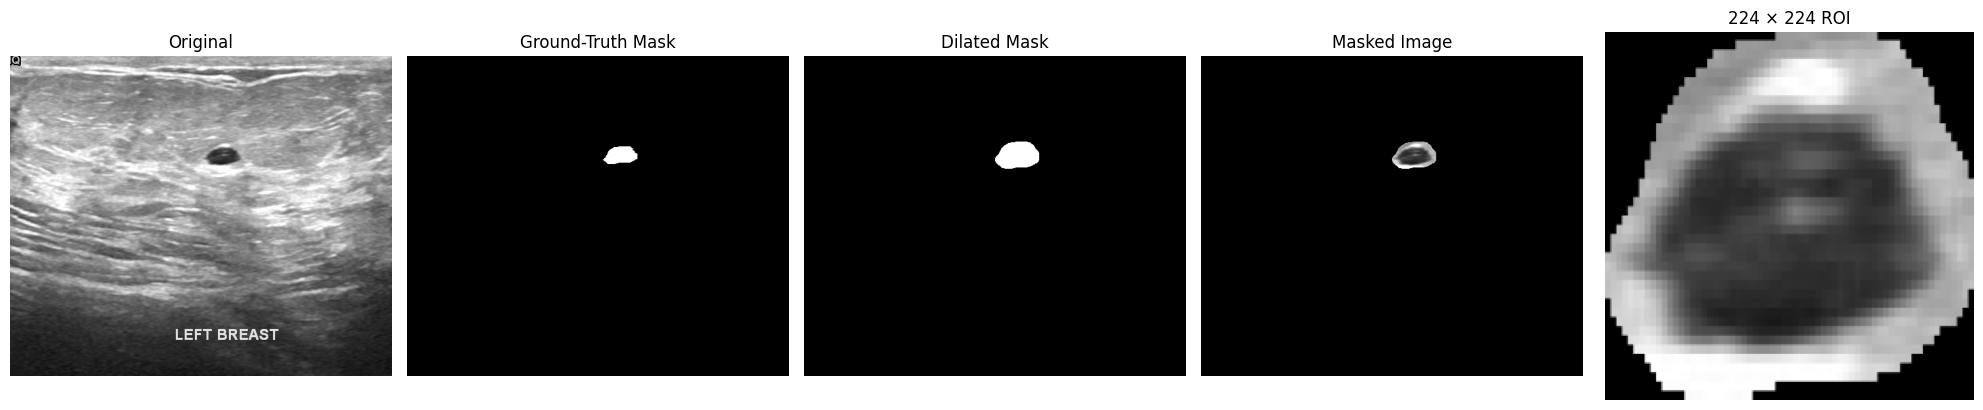

Example image: benign (1).png


In [5]:
def find_example_pair(root: Path, class_name: str = "benign"):
    """Select the first image with a corresponding BUSI ground-truth mask."""
    class_dir = root / class_name

    if not class_dir.exists():
        raise FileNotFoundError(f"Class directory not found: {class_dir}")

    image_files = sorted(
        p for p in class_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in SUPPORTED_EXTENSIONS
        and "_mask" not in p.stem.lower()
    )

    for image_path in image_files:
        mask_path = image_path.with_name(f"{image_path.stem}_mask{image_path.suffix}")
        if mask_path.exists():
            return image_path, mask_path

    raise FileNotFoundError(
        f"No image-mask pair found in {class_dir}"
    )


if ORIGINAL_ROOT.exists():
    sample_image_path, sample_mask_path = find_example_pair(
        ORIGINAL_ROOT, "benign"
    )

    original_bgr = cv2.imread(str(sample_image_path))
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(str(sample_mask_path), cv2.IMREAD_GRAYSCALE)
    binary_mask = (mask > 0).astype(np.uint8)
    dilated = dilate_mask(binary_mask, KERNEL_SIZE)

    masked = apply_mask(original_rgb, dilated)
    roi = crop_to_nonzero(masked)
    roi = cv2.resize(roi, TARGET_SIZE, interpolation=cv2.INTER_AREA)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(original_rgb, cmap="gray")
    axes[0].set_title("Original")

    axes[1].imshow(binary_mask, cmap="gray")
    axes[1].set_title("Ground-Truth Mask")

    axes[2].imshow(dilated, cmap="gray")
    axes[2].set_title("Dilated Mask")

    axes[3].imshow(masked)
    axes[3].set_title("Masked Image")

    axes[4].imshow(roi)
    axes[4].set_title("224 × 224 ROI")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Example image: {sample_image_path.name}")
else:
    print("Set ORIGINAL_ROOT to visualize the ROI extraction pipeline.")

## 7. Build the Raw ROI Dataset

For the **Raw ROI** condition, ROI extraction is applied directly to the original BUSI ultrasound images.

Only `benign` and `malignant` are included because the normal class does not have a lesion mask and therefore does not provide a lesion ROI for this workflow.

The output structure is:

```text
raw_roi_dataset/
├── benign/
└── malignant/
```

In [6]:
def list_images_with_masks(class_dir: Path):
    """Return original BUSI images that have corresponding ground-truth masks."""
    if not class_dir.exists():
        return []

    image_files = sorted(
        p for p in class_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in SUPPORTED_EXTENSIONS
        and "_mask" not in p.stem.lower()
    )

    pairs = []

    for image_path in image_files:
        mask_path = image_path.with_name(
            f"{image_path.stem}_mask{image_path.suffix}"
        )

        if mask_path.exists():
            pairs.append((image_path, mask_path))

    return pairs


def build_roi_dataset(
    image_root: Path,
    mask_root: Path,
    output_root: Path,
    target_size: tuple = TARGET_SIZE,
    kernel_size: int = KERNEL_SIZE,
):
    """Build an ROI dataset from image directories and corresponding mask directories."""
    for cls in CLASSES:
        image_dir = image_root / cls
        mask_dir = mask_root / cls
        output_dir = output_root / cls

        output_dir.mkdir(parents=True, exist_ok=True)

        pairs = list_images_with_masks(image_dir)

        saved = 0

        for image_path, _ in pairs:
            # Match the image to the mask stored in the original dataset.
            mask_path = mask_dir / f"{image_path.stem}_mask{image_path.suffix}"

            if not mask_path.exists():
                continue

            roi = generate_roi_from_image(
                image_path=image_path,
                mask_path=mask_path,
                target_size=target_size,
                kernel_size=kernel_size,
            )

            if roi is None:
                continue

            output_path = output_dir / image_path.name
            roi_bgr = cv2.cvtColor(roi, cv2.COLOR_RGB2BGR)

            if not cv2.imwrite(str(output_path), roi_bgr):
                raise IOError(f"Could not save ROI: {output_path}")

            saved += 1

        print(f"{cls:10s}: saved {saved} ROI images")


# Uncomment to generate the Raw ROI dataset:
#build_roi_dataset(
 #    image_root=ORIGINAL_ROOT,
  #   mask_root=ORIGINAL_ROOT,
   #  output_root=RAW_ROI_ROOT,
 #)

benign    : saved 437 ROI images
malignant : saved 210 ROI images


## 8. Build the Preprocessed ROI Dataset

For the **Preprocessed ROI** condition, the same ground-truth masks are applied to the images generated by `01_image_preprocessing.ipynb`.

This ensures that the experimental comparison differs in image preprocessing while using the same lesion-mask-based ROI definition.

The output structure is:

```text
preprocessed_roi_dataset/
├── benign/
└── malignant/
```

In [8]:
# Uncomment to generate the Preprocessed ROI dataset:
#
build_roi_dataset(
     image_root=PREPROCESSED_ROOT,
     mask_root=ORIGINAL_ROOT,
     output_root=PREPROCESSED_ROI_ROOT,
 )

benign    : saved 437 ROI images
malignant : saved 210 ROI images


## 9. Compare Raw ROI and Preprocessed ROI

A direct comparison helps verify that the same lesion region is being used while the image preprocessing differs.

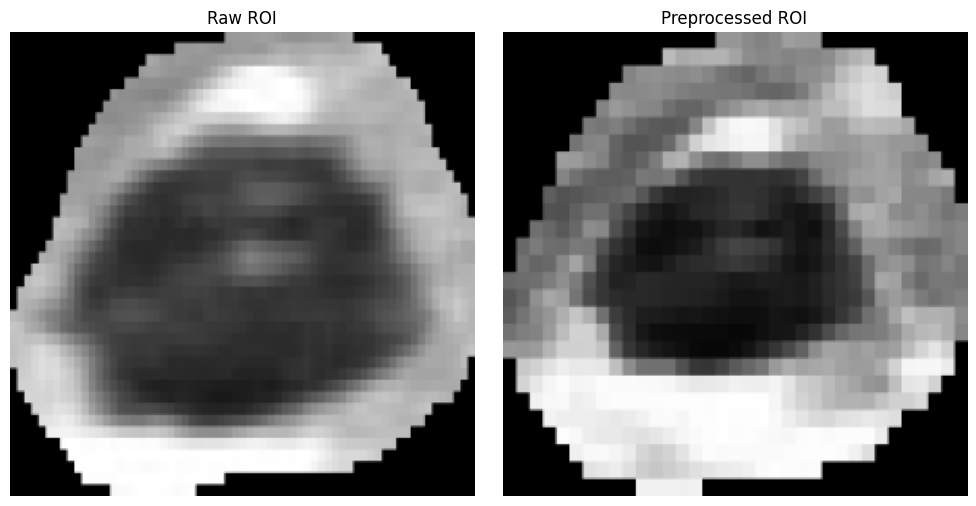

In [9]:
def load_rgb(path: Path) -> np.ndarray:
    """Load an image as RGB."""
    image = cv2.imread(str(path))
    if image is None:
        raise ValueError(f"Could not load image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


if RAW_ROI_ROOT.exists() and PREPROCESSED_ROI_ROOT.exists():
    raw_files = sorted(
        p for p in (RAW_ROI_ROOT / "benign").iterdir()
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
    )

    if raw_files:
        fname = raw_files[0].name
        raw_path = RAW_ROI_ROOT / "benign" / fname
        prep_path = PREPROCESSED_ROI_ROOT / "benign" / fname

        if prep_path.exists():
            raw = load_rgb(raw_path)
            prep = load_rgb(prep_path)

            fig, axes = plt.subplots(1, 2, figsize=(10, 5))

            axes[0].imshow(raw)
            axes[0].set_title("Raw ROI")
            axes[0].axis("off")

            axes[1].imshow(prep)
            axes[1].set_title("Preprocessed ROI")
            axes[1].axis("off")

            plt.tight_layout()
            plt.show()
        else:
            print("Matching preprocessed ROI not found.")
    else:
        print("No Raw ROI images found.")
else:
    print(
        "Generate both ROI datasets before running this comparison."
    )

## 10. Quality Checks

The ROI outputs should satisfy the expected image dimensions and class structure.

The following helper checks a sample of generated files.

In [10]:
def verify_roi_dataset(root: Path) -> None:
    """Report image counts and sample dimensions for an ROI dataset."""
    if not root.exists():
        print(f"Dataset not found: {root}")
        return

    for cls in CLASSES:
        class_dir = root / cls

        if not class_dir.exists():
            print(f"{cls:10s}: directory missing")
            continue

        files = sorted(
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
        )

        dimensions = set()

        for path in files[:10]:
            image = load_rgb(path)
            dimensions.add(image.shape[:2])

        print(
            f"{cls:10s}: {len(files)} images | "
            f"sample dimensions: {sorted(dimensions)}"
        )


# Uncomment after generating the datasets:
#verify_roi_dataset(RAW_ROI_ROOT)
#verify_roi_dataset(PREPROCESSED_ROI_ROOT)

benign    : 437 images | sample dimensions: [(224, 224)]
malignant : 210 images | sample dimensions: [(224, 224)]
benign    : 437 images | sample dimensions: [(224, 224)]
malignant : 210 images | sample dimensions: [(224, 224)]


## 11. Experimental Outputs

This notebook produces two lesion-focused image sets:

### Raw ROI

```text
raw_roi_dataset/
├── benign/
└── malignant/
```

### Preprocessed ROI

```text
preprocessed_roi_dataset/
├── benign/
└── malignant/
```

Both use the same BUSI ground-truth masks and a `15 × 15` elliptical dilation kernel, with final dimensions of `224 × 224`.

These datasets form two of the input conditions evaluated in the downstream VGG16 classification experiments.

### Next notebook

**`03_vgg16_model_comparison.ipynb`** — evaluates the classification model across whole-image, raw-ROI, and preprocessed-ROI conditions.